Task 1 – GD on a curve with two valleys


1 step, w = 0.5, g = -1.5, new w = 0.65, new L = 0.3335062499999999
2 step, w = 0.65, g = -1.5015, new w = 0.80015, new L = 0.1294272414108005
g at w = -0.5 -> 1.5
Updated w = -0.65
first w = 1.5
at n=0.1, new w -> 0.75, right valley
at n=0.2, new w -> 0.0, on the bump
at n=0.24, new w -> -0.2999999999999998, past the bump


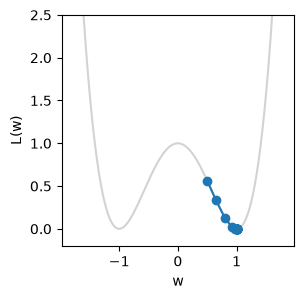

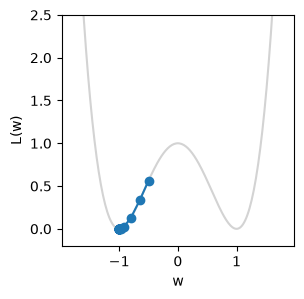

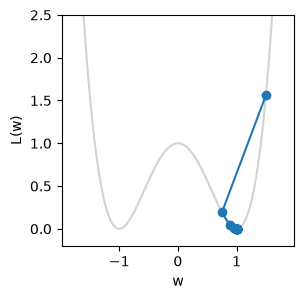

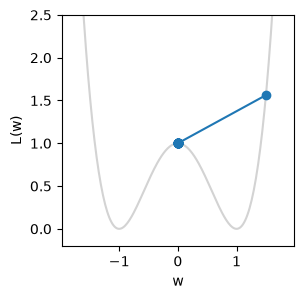

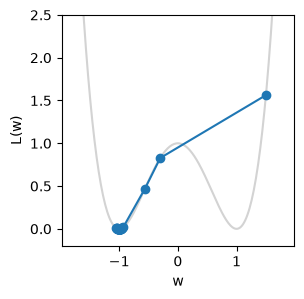

In [24]:
#1
import numpy as np

n = 0.1
w = 0.5 
ws = []
L = []
for i in range(2):
    w_new = w - n * (4*w**3 - 4*w)
    g = 4*w**3 - 4*w
    l = (w_new**2-1)**2
    print(f'{i+1} step, w = {w}, g = {g}, new w = {w_new}, new L = {l}')
    w = w_new
    
#2
w_0 = -0.5
n = 0.1
print(f'g at w = -0.5 -> {4*w_0**3 - 4*w_0}')
print(f'Updated w = {w_0 - n * (4*w_0**3 - 4*w_0)}')

#3
w_0 = 1.5 
g = 7.5
n = [0.1,0.2,0.24]
print("first w = 1.5")
for eta in n:
    w_new = w_0 - eta * (4*w_0**3 - 4*w_0)
    if w_new > 0:
        place = "right valley"
    elif w_new == 0:
        place = "on the bump"
    else:
        place = "past the bump"
    print(f"at n={eta}, new w -> {w_new}, {place}")
    
#4
import matplotlib.pyplot as plt

def loss(w):
    return (w**2 - 1)**2

def gradient(w):
    return 4*w**3 - 4*w

def gd(w_0, eta, step=30):
    w = w_0
    points = [w]
    
    for i in range(step):
        g = gradient(w)
        w = w - eta * g
        points.append(w)

    return points

runs = [
    (0.5, 0.1),
    (-0.5, 0.1),
    (1.5, 0.1),
    (1.5, 0.2),
    (1.5, 0.24)
]

for i in runs:
    points = gd(i[0], i[1])

    w_grid = np.linspace(-1.8, 1.8, 200)
    plt.figure(figsize=(3,3))
    plt.plot(w_grid, (w_grid**2 - 1)**2, color="lightgray")
    plt.plot(points, (np.array(points)**2 - 1)**2, "o-") # points = [w0, w1, ..., w30]
    plt.ylim(-0.2, 2.5); plt.xlabel("w"); plt.ylabel("L(w)"); plt.show()